# Smart Outcome Predictor
### Supervised Learning - Ensemble Methods

In this project we are building a machine learning system to predict student outcomes on an online course platform.

We have 2 tasks:
- **Classification** - Will the student complete the course or not? (completion_status)
- **Regression** - What will be the student's final score? (final_score)

We will use ensemble methods like bagging, boosting, voting and stacking.

---
## Part A: Theory Questions

**Q1. What are Ensemble Learning Methods and why are they effective?**

Ensemble methods combine multiple models together to get a better prediction than any single model. Instead of relying on one model, we train many models and combine their results. They are effective because a group of models can cover each other's weaknesses - if one model makes a mistake, the others can correct it.

**Q2. Difference between Bagging, Boosting and Voting**

- **Bagging** - We take random samples of data, train separate models on each sample, and then average their predictions. Models are independent of each other. Example: Random Forest.
- **Boosting** - We train models one after another. Each new model tries to fix the errors of the previous one. Models are dependent on each other. Example: AdaBoost, XGBoost.
- **Voting** - We train completely different types of models (like LR, DT, KNN) on the same data and let them vote for the final answer.

**Q3. What is Bias-Variance Trade-off and how do ensemble methods address it?**

Bias means the model is too simple and misses patterns (underfitting). Variance means the model is too complex and memorizes noise (overfitting). We can't reduce both at the same time easily.
- Bagging reduces variance by averaging many models
- Boosting reduces bias by correcting errors step by step

**Q4. Voting Classifier and Stacking Ensemble**

- **Voting Classifier** - Multiple models vote. In hard voting we take majority vote. In soft voting we average the probabilities.
- **Stacking** - The predictions of base models are used as input features for another model (called meta-learner). The meta-learner learns which model to trust more.

**Q5. Compare AdaBoost, Gradient Boosting, LightGBM and XGBoost**

- **AdaBoost** - Gives more weight to wrongly classified samples. Simple but sensitive to noise.
- **Gradient Boosting** - Fits new trees on residual errors. More flexible but slow.
- **LightGBM** - Uses histogram based splitting, very fast. Good for large data.
- **XGBoost** - Like gradient boosting but with regularization (L1 and L2). Prevents overfitting better.

---
## Part B: Dataset Understanding and Preparation

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [21]:
df = pd.read_csv("Smart_Outcome_Predictor_Dataset_5200 - Smart_Outcome_Predictor_Dataset_5200.csv.csv")
print("Shape:", df.shape)
df.head()

Shape: (5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   object 
 3   device_type            5200 non-null   object 
 4   education_background   5200 non-null   object 
 5   course_level           5200 non-null   object 
 6   course_category        5200 non-null   object 
 7   course_start_date      5200 non-null   object 
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null   int64  
 15  avg_

In [23]:
df.describe()

,student_id,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
count,5200.000000,5200.000000,5200.000000,5200.000000,5088.000000,5200.000000,5200.000000,5200.000000,5200.000000,5119.000000,5120.000000,5200.000000,5200.000000
mean,702600.500000,24.339615,26.621538,19.121923,18.216156,25.852885,6.995769,3.835769,1.585577,66.842626,0.847189,0.375385,74.821615
std,1501.255031,5.578864,15.007731,10.726708,10.734114,17.720493,2.568017,1.951802,1.270640,13.813992,0.113545,0.484269,13.531829
min,700001.000000,16.000000,1.000000,1.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.313000,0.000000,35.200000
25%,701300.750000,20.000000,14.000000,11.000000,10.300000,13.000000,5.000000,2.000000,1.000000,57.500000,0.768750,0.000000,64.700000
50%,702600.500000,24.000000,27.000000,17.000000,16.100000,23.000000,7.000000,4.000000,1.000000,66.900000,0.855000,0.000000,74.100000
75%,703900.250000,28.000000,40.000000,25.000000,23.800000,35.000000,9.000000,5.000000,2.000000,76.200000,0.942000,1.000000,84.900000
max,705200.000000,45.000000,52.000000,94.000000,76.800000,158.000000,20.000000,12.000000,8.000000,100.000000,1.000000,1.000000,100.000000


In [24]:
print("Missing values:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing values:
student_id                 0
age                        0
country_region             0
device_type                0
education_background       0
course_level               0
course_category            0
course_start_date          0
week_of_year               0
sessions                   0
time_spent_hours         112
videos_watched             0
quiz_attempts              0
assignments_submitted      0
forum_posts                0
avg_quiz_score            81
attendance_rate           80
completion_status          0
final_score                0
dtype: int64

Total missing: 273


There are some missing values in the dataset. We will handle them using median imputation after train-test split.

In [25]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [26]:
print("completion_status value counts:")
print(df['completion_status'].value_counts())
print()
print("final_score stats:")
print(f"Min: {df['final_score'].min()}, Max: {df['final_score'].max()}, Mean: {df['final_score'].mean():.2f}")

completion_status value counts:
completion_status
0    3248
1    1952
Name: count, dtype: int64

final_score stats:
Min: 35.2, Max: 100.0, Mean: 74.82


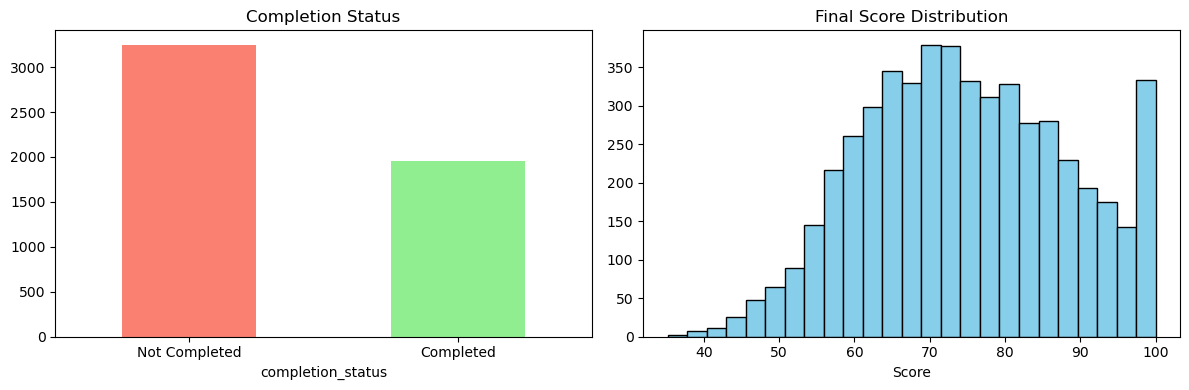

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df['completion_status'].value_counts().plot(kind='bar', ax=ax[0], color=['salmon', 'lightgreen'])
ax[0].set_title('Completion Status')
ax[0].set_xticklabels(['Not Completed', 'Completed'], rotation=0)

ax[1].hist(df['final_score'], bins=25, color='skyblue', edgecolor='black')
ax[1].set_title('Final Score Distribution')
ax[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

In [28]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts())
    print()

country_region: 5 unique values
country_region
Asia        1984
Americas    1176
Europe      1152
Africa       664
Oceania      224
Name: count, dtype: int64

device_type: 3 unique values
device_type
Mobile    3020
Laptop    1762
Tablet     418
Name: count, dtype: int64

education_background: 4 unique values
education_background
Undergrad     2311
Graduate      1032
WorkingPro     951
HighSchool     906
Name: count, dtype: int64

course_level: 3 unique values
course_level
Beginner        2264
Intermediate    2076
Advanced         860
Name: count, dtype: int64

course_category: 5 unique values
course_category
Data           1525
Programming    1340
Business        951
Design          737
Marketing       647
Name: count, dtype: int64

course_start_date: 365 unique values
course_start_date
2024-12-16    30
2024-06-07    28
2024-11-02    28
2024-06-13    24
2024-06-15    24
              ..
2024-12-05     7
2024-05-13     6
2024-09-01     6
2024-02-12     6
2024-02-28     5
Name: count, Le

### Task 6-8: Features, Train-Test Split and Preprocessing

We need to:
- Drop course_start_date (we already have week_of_year)
- Encode categorical columns
- Split into train and test
- Handle missing values
- Scale the features

In [29]:
from sklearn.preprocessing import LabelEncoder

df_clean = df.drop(columns=['course_start_date'])

label_encoders = {}
cat_features = ['country_region', 'device_type', 'education_background', 'course_level', 'course_category']

for col in cat_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

print("After encoding:")
df_clean.head()

After encoding:


,student_id,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,3,0,2,2,0,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,3,0,2,2,4,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,3,1,0,0,4,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,2,1,2,1,2,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,2,2,3,0,0,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


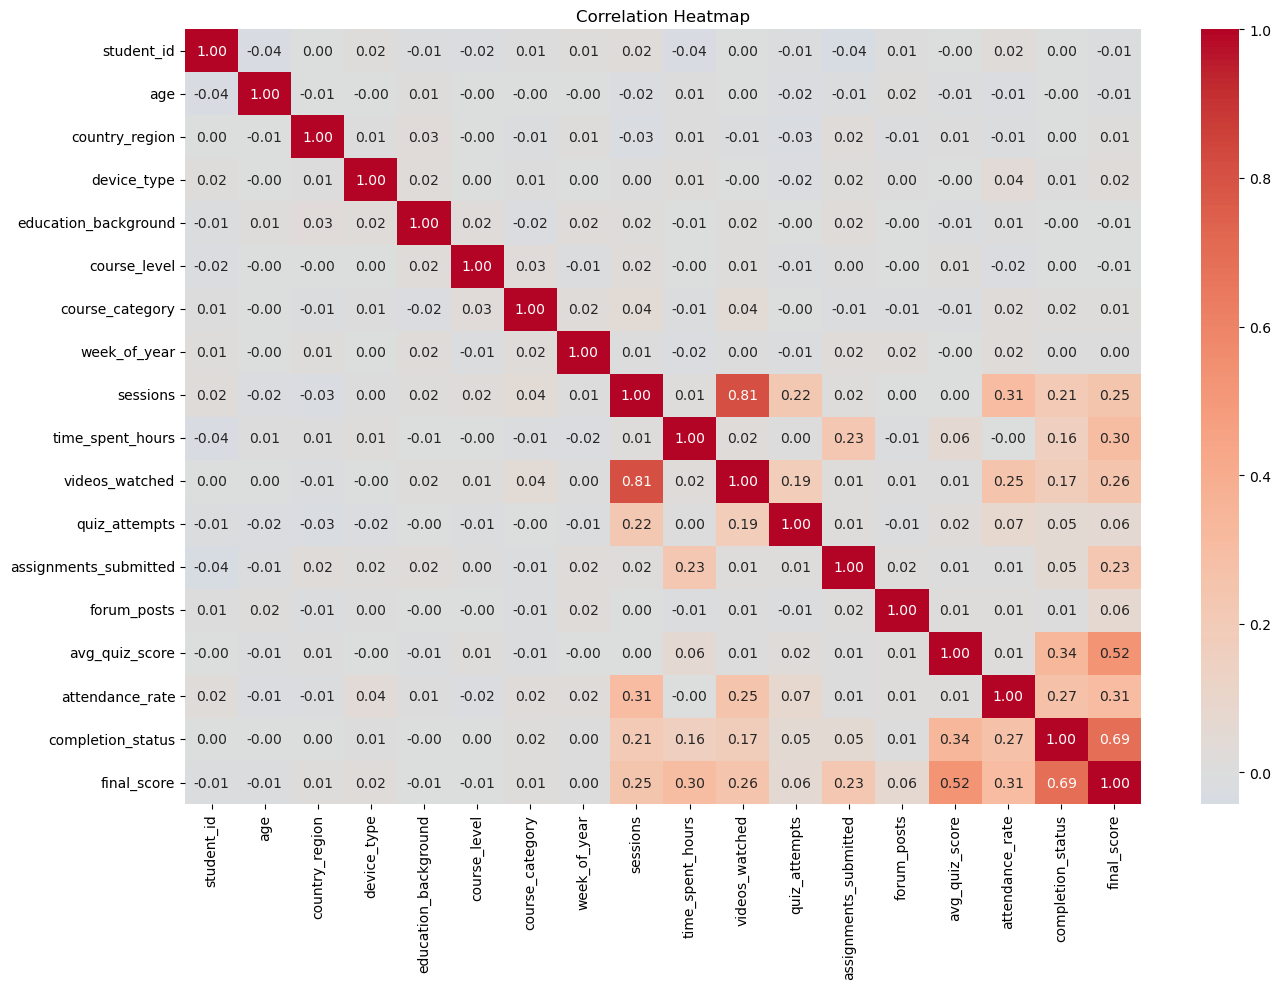

In [30]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [31]:
X = df_clean.drop(columns=['completion_status', 'final_score'])
y_class = df_clean['completion_status']
y_reg = df_clean['final_score']

print("Features:", list(X.columns))
print("Shape:", X.shape)

Features: ['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']
Shape: (5200, 16)


In [32]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print("Train size:", X_train_c.shape[0])
print("Test size:", X_test_c.shape[0])

Train size: 4160
Test size: 1040


In [33]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_c = pd.DataFrame(imputer.fit_transform(X_train_c), columns=X.columns, index=X_train_c.index)
X_test_c = pd.DataFrame(imputer.transform(X_test_c), columns=X.columns, index=X_test_c.index)

imputer2 = SimpleImputer(strategy='median')
X_train_r = pd.DataFrame(imputer2.fit_transform(X_train_r), columns=X.columns, index=X_train_r.index)
X_test_r = pd.DataFrame(imputer2.transform(X_test_r), columns=X.columns, index=X_test_r.index)

print("Missing after imputation:", X_train_c.isnull().sum().sum())

Missing after imputation: 0


In [34]:
from sklearn.preprocessing import StandardScaler

scaler_c = StandardScaler()
X_train_cs = pd.DataFrame(scaler_c.fit_transform(X_train_c), columns=X.columns, index=X_train_c.index)
X_test_cs = pd.DataFrame(scaler_c.transform(X_test_c), columns=X.columns, index=X_test_c.index)

scaler_r = StandardScaler()
X_train_rs = pd.DataFrame(scaler_r.fit_transform(X_train_r), columns=X.columns, index=X_train_r.index)
X_test_rs = pd.DataFrame(scaler_r.transform(X_test_r), columns=X.columns, index=X_test_r.index)

print("Scaling done")
X_train_cs.head()

Scaling done


,student_id,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate
849,-1.152565,-0.422862,1.130968,0.431052,0.391755,-0.320831,-0.660228,0.813102,-0.384893,-0.194625,-0.044329,-0.387688,-0.950149,-1.244981,-2.246119,0.076095
4574,1.327689,1.728292,-1.740747,0.431052,-1.605426,-0.320831,1.372245,-1.178441,-0.013288,-0.822921,-0.044329,-0.387688,0.589233,1.104181,0.698163,-1.679531
2082,-0.331584,-0.422862,0.173729,0.431052,-0.606836,1.073793,0.017263,0.680332,-1.406809,-0.363421,-1.452452,-0.777343,1.102360,-0.461927,1.701562,-0.093229
1157,-0.947486,1.728292,1.130968,0.431052,0.391755,-1.715454,1.372245,-0.846517,-1.499710,1.802794,-1.452452,0.001967,-0.950149,0.321127,-0.678765,-1.020057
957,-1.080654,1.011241,2.088206,2.121131,0.391755,1.073793,1.372245,0.481178,0.172515,-0.625992,-0.494928,1.950242,-0.437022,0.321127,0.478440,-0.004111


---
## Part C: Bagging (Bootstrap Aggregating)

In bagging we create random subsets of data, train a model on each, and combine results.

### Task 9: Bagging Classifier

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_cs, y_train_c)
dt_pred_c = dt_clf.predict(X_test_cs)

print("--- Single Decision Tree (Baseline) ---")
print("Accuracy:", round(accuracy_score(y_test_c, dt_pred_c), 4))
print("F1 Score:", round(f1_score(y_test_c, dt_pred_c), 4))

--- Single Decision Tree (Baseline) ---
Accuracy: 0.6144
F1 Score: 0.5019


In [36]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                            n_estimators=100, max_samples=0.8,
                            random_state=42, n_jobs=-1)
bag_clf.fit(X_train_cs, y_train_c)
bag_pred_c = bag_clf.predict(X_test_cs)

print("--- Bagging Classifier ---")
print("Accuracy:", round(accuracy_score(y_test_c, bag_pred_c), 4))
print("Precision:", round(precision_score(y_test_c, bag_pred_c), 4))
print("Recall:", round(recall_score(y_test_c, bag_pred_c), 4))
print("F1 Score:", round(f1_score(y_test_c, bag_pred_c), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_c, bag_pred_c), 4))

--- Bagging Classifier ---
Accuracy: 0.7096
Precision: 0.6302
Recall: 0.5462
F1 Score: 0.5852
ROC-AUC: 0.6769


### Task 10: Bagging Regressor

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_rs, y_train_r)
dt_pred_r = dt_reg.predict(X_test_rs)

print("--- Single Decision Tree Regressor ---")
print("MAE:", round(mean_absolute_error(y_test_r, dt_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, dt_pred_r)), 4))
print("R2 Score:", round(r2_score(y_test_r, dt_pred_r), 4))

--- Single Decision Tree Regressor ---
MAE: 11.0985
RMSE: 14.0436
R2 Score: -0.0556


In [38]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

bag_reg = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                           n_estimators=100, max_samples=0.8,
                           random_state=42, n_jobs=-1)
bag_reg.fit(X_train_rs, y_train_r)
bag_pred_r = bag_reg.predict(X_test_rs)

print("--- Bagging Regressor ---")
print("MAE:", round(mean_absolute_error(y_test_r, bag_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, bag_pred_r)), 4))
print("R2 Score:", round(r2_score(y_test_r, bag_pred_r), 4))

--- Bagging Regressor ---
MAE: 7.9766
RMSE: 9.9559
R2 Score: 0.4695


### Task 11: Bagging vs Single Model Comparison

In [39]:
from sklearn.metrics import accuracy_score, r2_score

print("Classification Comparison:")
print(f"  Single DT Accuracy: {accuracy_score(y_test_c, dt_pred_c):.4f}")
print(f"  Bagging Accuracy:   {accuracy_score(y_test_c, bag_pred_c):.4f}")
print()
print("Regression Comparison:")
print(f"  Single DT R2: {r2_score(y_test_r, dt_pred_r):.4f}")
print(f"  Bagging R2:   {r2_score(y_test_r, bag_pred_r):.4f}")
print()
print("Bagging improves over single tree because averaging multiple trees reduces overfitting.")

Classification Comparison:
  Single DT Accuracy: 0.6144
  Bagging Accuracy:   0.7096

Regression Comparison:
  Single DT R2: -0.0556
  Bagging R2:   0.4695

Bagging improves over single tree because averaging multiple trees reduces overfitting.


---
## Part D: Boosting Algorithms

### AdaBoost

In [40]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

ada_clf = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                             n_estimators=100, learning_rate=0.5, random_state=42)
ada_clf.fit(X_train_cs, y_train_c)
ada_pred_c = ada_clf.predict(X_test_cs)

print("--- AdaBoost Classifier ---")
print("Accuracy:", round(accuracy_score(y_test_c, ada_pred_c), 4))
print("Precision:", round(precision_score(y_test_c, ada_pred_c), 4))
print("Recall:", round(recall_score(y_test_c, ada_pred_c), 4))
print("F1 Score:", round(f1_score(y_test_c, ada_pred_c), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_c, ada_pred_c), 4))

--- AdaBoost Classifier ---
Accuracy: 0.7356
Precision: 0.6873
Recall: 0.541
F1 Score: 0.6055
ROC-AUC: 0.6967


In [41]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ada_reg = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
                            n_estimators=100, learning_rate=0.5, random_state=42)
ada_reg.fit(X_train_rs, y_train_r)
ada_pred_r = ada_reg.predict(X_test_rs)

print("--- AdaBoost Regressor ---")
print("MAE:", round(mean_absolute_error(y_test_r, ada_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, ada_pred_r)), 4))
print("R2 Score:", round(r2_score(y_test_r, ada_pred_r), 4))

--- AdaBoost Regressor ---
MAE: 8.5253
RMSE: 10.493
R2 Score: 0.4107


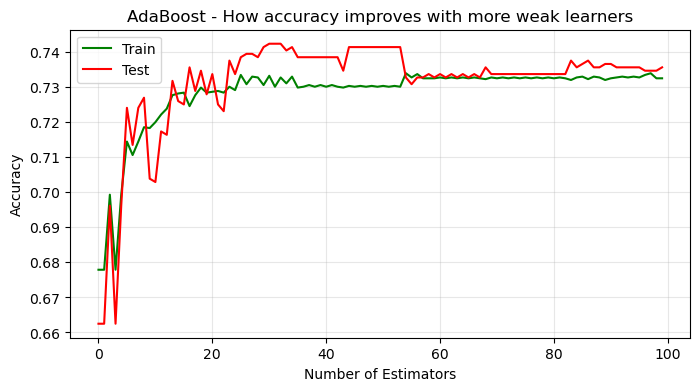

With 1 estimator: 0.6625
With 100 estimators: 0.7356


In [42]:
train_scores = list(ada_clf.staged_score(X_train_cs, y_train_c))
test_scores = list(ada_clf.staged_score(X_test_cs, y_test_c))

plt.figure(figsize=(8, 4))
plt.plot(train_scores, label='Train', color='green')
plt.plot(test_scores, label='Test', color='red')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('AdaBoost - How accuracy improves with more weak learners')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"With 1 estimator: {test_scores[0]:.4f}")
print(f"With 100 estimators: {test_scores[-1]:.4f}")

We can see that as we add more weak learners, the accuracy keeps improving. This is the key idea of boosting - each new model corrects the mistakes of previous ones.

### Gradient Boosting

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train_cs, y_train_c)
gb_pred_c = gb_clf.predict(X_test_cs)

print("--- Gradient Boosting Classifier ---")
print("Accuracy:", round(accuracy_score(y_test_c, gb_pred_c), 4))
print("Precision:", round(precision_score(y_test_c, gb_pred_c), 4))
print("Recall:", round(recall_score(y_test_c, gb_pred_c), 4))
print("F1 Score:", round(f1_score(y_test_c, gb_pred_c), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_c, gb_pred_c), 4))

--- Gradient Boosting Classifier ---
Accuracy: 0.7365
Precision: 0.6747
Recall: 0.5744
F1 Score: 0.6205
ROC-AUC: 0.7041


In [44]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_reg.fit(X_train_rs, y_train_r)
gb_pred_r = gb_reg.predict(X_test_rs)

print("--- Gradient Boosting Regressor ---")
print("MAE:", round(mean_absolute_error(y_test_r, gb_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, gb_pred_r)), 4))
print("R2 Score:", round(r2_score(y_test_r, gb_pred_r), 4))

--- Gradient Boosting Regressor ---
MAE: 7.8786
RMSE: 9.8101
R2 Score: 0.4849


Learning Rate = 0.01 -> Accuracy = 0.6990
Learning Rate = 0.05 -> Accuracy = 0.7423
Learning Rate = 0.1 -> Accuracy = 0.7365
Learning Rate = 0.2 -> Accuracy = 0.7231
Learning Rate = 0.5 -> Accuracy = 0.6846


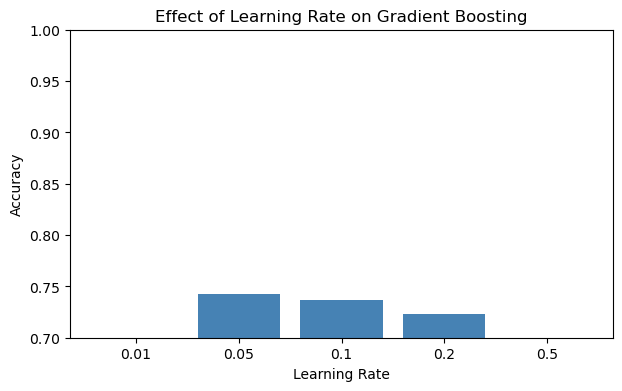


Learning rate 0.1 seems to give the best results.


Learning Rate = 0.2 -> Accuracy = 0.7221


Learning Rate = 0.5 -> Accuracy = 0.6962


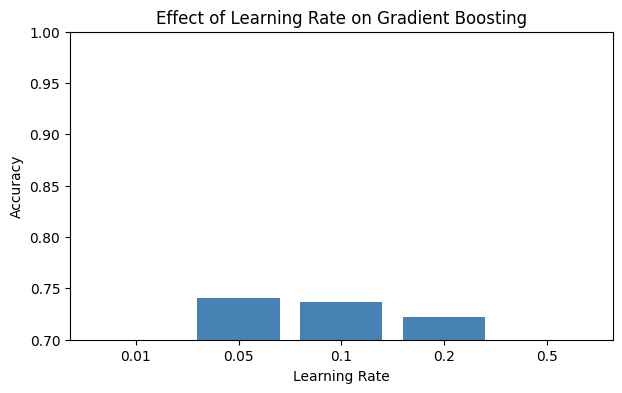


Learning rate 0.1 seems to give the best results.


In [45]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

lr_values = [0.01, 0.05, 0.1, 0.2, 0.5]
lr_results = []

for lr in lr_values:
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    model.fit(X_train_cs, y_train_c)
    pred = model.predict(X_test_cs)
    acc = accuracy_score(y_test_c, pred)
    lr_results.append(acc)
    print(f"Learning Rate = {lr} -> Accuracy = {acc:.4f}")

plt.figure(figsize=(7, 4))
plt.bar([str(x) for x in lr_values], lr_results, color='steelblue')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Effect of Learning Rate on Gradient Boosting')
plt.ylim(0.7, 1.0)
plt.show()

print("\nLearning rate 0.1 seems to give the best results.")

### LightGBM

In [46]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lgbm_clf = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1)
lgbm_clf.fit(X_train_cs, y_train_c)
lgbm_pred_c = lgbm_clf.predict(X_test_cs)

print("--- LightGBM Classifier ---")
print("Accuracy:", round(accuracy_score(y_test_c, lgbm_pred_c), 4))
print("Precision:", round(precision_score(y_test_c, lgbm_pred_c), 4))
print("Recall:", round(recall_score(y_test_c, lgbm_pred_c), 4))
print("F1 Score:", round(f1_score(y_test_c, lgbm_pred_c), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_c, lgbm_pred_c), 4))

ModuleNotFoundError: No module named 'lightgbm'

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lgbm_reg = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbose=-1)
lgbm_reg.fit(X_train_rs, y_train_r)
lgbm_pred_r = lgbm_reg.predict(X_test_rs)

print("--- LightGBM Regressor ---")
print("MAE:", round(mean_absolute_error(y_test_r, lgbm_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, lgbm_pred_r)), 4))
print("R2 Score:", round(r2_score(y_test_r, lgbm_pred_r), 4))

In [ ]:
import time
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier

for name, model in [('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42)),
                     ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
                     ('LightGBM', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))]:
    start = time.time()
    model.fit(X_train_cs, y_train_c)
    t = time.time() - start
    print(f"{name}: {t:.3f} seconds")

print("\nLightGBM is clearly the fastest.")

Gradient Boosting: 0.749 seconds
LightGBM: 0.133 seconds

LightGBM is clearly the fastest.


### XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
xgb_clf.fit(X_train_cs, y_train_c)
xgb_pred_c = xgb_clf.predict(X_test_cs)

print("--- XGBoost Classifier ---")
print("Accuracy:", round(accuracy_score(y_test_c, xgb_pred_c), 4))
print("Precision:", round(precision_score(y_test_c, xgb_pred_c), 4))
print("Recall:", round(recall_score(y_test_c, xgb_pred_c), 4))
print("F1 Score:", round(f1_score(y_test_c, xgb_pred_c), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_c, xgb_pred_c), 4))

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_reg.fit(X_train_rs, y_train_r)
xgb_pred_r = xgb_reg.predict(X_test_rs)

print("--- XGBoost Regressor ---")
print("MAE:", round(mean_absolute_error(y_test_r, xgb_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, xgb_pred_r)), 4))
print("R2 Score:", round(r2_score(y_test_r, xgb_pred_r), 4))

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score

print("=== Boosting Classifiers ===")
for name, pred in [('AdaBoost', ada_pred_c), ('Gradient Boosting', gb_pred_c),
                    ('LightGBM', lgbm_pred_c), ('XGBoost', xgb_pred_c)]:
    print(f"{name:20s} Acc={accuracy_score(y_test_c, pred):.4f}  F1={f1_score(y_test_c, pred):.4f}")

print("\n=== Boosting Regressors ===")
for name, pred in [('AdaBoost', ada_pred_r), ('Gradient Boosting', gb_pred_r),
                    ('LightGBM', lgbm_pred_r), ('XGBoost', xgb_pred_r)]:
    print(f"{name:20s} MAE={mean_absolute_error(y_test_r, pred):.4f}  R2={r2_score(y_test_r, pred):.4f}")

---
## Part E: Voting and Stacking Ensembles

In [ ]:
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

hard_vote = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
                ('knn', KNeighborsClassifier(n_neighbors=5)),
                ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42))],
    voting='hard')

hard_vote.fit(X_train_cs, y_train_c)
hv_pred = hard_vote.predict(X_test_cs)

print("--- Hard Voting ---")
print("Accuracy:", round(accuracy_score(y_test_c, hv_pred), 4))
print("F1 Score:", round(f1_score(y_test_c, hv_pred), 4))

In [ ]:
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

soft_vote = VotingClassifier(
    estimators=[('lr', LogisticRegression(max_iter=1000, random_state=42)),
                ('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
                ('knn', KNeighborsClassifier(n_neighbors=5)),
                ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42))],
    voting='soft')

soft_vote.fit(X_train_cs, y_train_c)
sv_pred = soft_vote.predict(X_test_cs)

print("--- Soft Voting ---")
print("Accuracy:", round(accuracy_score(y_test_c, sv_pred), 4))
print("F1 Score:", round(f1_score(y_test_c, sv_pred), 4))
print()
print(f"Hard Voting: {accuracy_score(y_test_c, hv_pred):.4f}")
print(f"Soft Voting: {accuracy_score(y_test_c, sv_pred):.4f}")
print("Soft voting uses probability info so it usually performs slightly better.")

In [ ]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

stack_clf = StackingClassifier(
    estimators=[('dt', DecisionTreeClassifier(max_depth=10, random_state=42)),
                ('knn', KNeighborsClassifier(n_neighbors=5)),
                ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
                ('lgbm', LGBMClassifier(n_estimators=50, random_state=42, verbose=-1))],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5)

stack_clf.fit(X_train_cs, y_train_c)
stack_pred_c = stack_clf.predict(X_test_cs)

print("--- Stacking Classifier ---")
print("Accuracy:", round(accuracy_score(y_test_c, stack_pred_c), 4))
print("Precision:", round(precision_score(y_test_c, stack_pred_c), 4))
print("Recall:", round(recall_score(y_test_c, stack_pred_c), 4))
print("F1 Score:", round(f1_score(y_test_c, stack_pred_c), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_c, stack_pred_c), 4))

In [ ]:
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

stack_reg = StackingRegressor(
    estimators=[('dt', DecisionTreeRegressor(max_depth=10, random_state=42)),
                ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42)),
                ('lgbm', LGBMRegressor(n_estimators=50, random_state=42, verbose=-1)),
                ('xgb', XGBRegressor(n_estimators=50, random_state=42))],
    final_estimator=Ridge(alpha=1.0),
    cv=5)

stack_reg.fit(X_train_rs, y_train_r)
stack_pred_r = stack_reg.predict(X_test_rs)

print("--- Stacking Regressor ---")
print("MAE:", round(mean_absolute_error(y_test_r, stack_pred_r), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_r, stack_pred_r)), 4))
print("R2 Score:", round(r2_score(y_test_r, stack_pred_r), 4))

---
## Part F: Model Evaluation and Comparison

### Task 28: Classification Models Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

all_clf = {'Single DT': dt_pred_c, 'Bagging': bag_pred_c,
           'AdaBoost': ada_pred_c, 'Gradient Boosting': gb_pred_c,
           'LightGBM': lgbm_pred_c, 'XGBoost': xgb_pred_c,
           'Hard Voting': hv_pred, 'Soft Voting': sv_pred,
           'Stacking': stack_pred_c}

rows = []
for name, pred in all_clf.items():
    rows.append({'Model': name,
                 'Accuracy': round(accuracy_score(y_test_c, pred), 4),
                 'Precision': round(precision_score(y_test_c, pred), 4),
                 'Recall': round(recall_score(y_test_c, pred), 4),
                 'F1-Score': round(f1_score(y_test_c, pred), 4),
                 'ROC-AUC': round(roc_auc_score(y_test_c, pred), 4)})

clf_table = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("CLASSIFICATION RESULTS")
print(clf_table.to_string(index=False))

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(clf_table['Model'], clf_table['Accuracy'], color='steelblue')
plt.xlabel('Accuracy')
plt.title('Classification Models - Accuracy Comparison')
plt.xlim(0.65, 1.0)
for i, v in enumerate(clf_table['Accuracy']):
    plt.text(v + 0.003, i, str(v), va='center')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

top4 = clf_table['Model'].head(4).tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, name in enumerate(top4):
    cm = confusion_matrix(y_test_c, all_clf[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Task 29: Regression Models Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

all_reg = {'Single DT': dt_pred_r, 'Bagging': bag_pred_r,
           'AdaBoost': ada_pred_r, 'Gradient Boosting': gb_pred_r,
           'LightGBM': lgbm_pred_r, 'XGBoost': xgb_pred_r,
           'Stacking': stack_pred_r}

rows_r = []
for name, pred in all_reg.items():
    rows_r.append({'Model': name,
                   'MAE': round(mean_absolute_error(y_test_r, pred), 4),
                   'RMSE': round(np.sqrt(mean_squared_error(y_test_r, pred)), 4),
                   'R2 Score': round(r2_score(y_test_r, pred), 4)})

reg_table = pd.DataFrame(rows_r).sort_values('R2 Score', ascending=False).reset_index(drop=True)
print("REGRESSION RESULTS")
print(reg_table.to_string(index=False))

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(reg_table['Model'], reg_table['R2 Score'], color='coral')
plt.xlabel('R2 Score')
plt.title('Regression Models - R2 Score Comparison')
for i, v in enumerate(reg_table['R2 Score']):
    plt.text(v + 0.005, i, str(v), va='center')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

top3_r = reg_table['Model'].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, name in enumerate(top3_r):
    pred = all_reg[name]
    axes[i].scatter(y_test_r, pred, alpha=0.3, s=10)
    axes[i].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
    axes[i].set_title(f'{name} (R2={r2_score(y_test_r, pred):.3f})')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

### Task 30: Best Model Selection

In [ ]:
print("FINAL COMPARISON")
print("="*50)
print("\nClassification Results:")
print(clf_table.to_string(index=False))
print(f"\nBest: {clf_table.iloc[0]['Model']} with accuracy {clf_table.iloc[0]['Accuracy']}")

print("\nRegression Results:")
print(reg_table.to_string(index=False))
print(f"\nBest: {reg_table.iloc[0]['Model']} with R2 {reg_table.iloc[0]['R2 Score']}")

---
## Part G: Final Analysis and Reporting

In [ ]:
feat_imp = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (XGBoost Classifier)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Final Report

**1. Bagging vs Boosting**

Bagging improved over a single decision tree because it averages many trees and reduces overfitting. But boosting methods performed even better because they also reduce bias by fixing errors step by step.

**2. Boosting Algorithms Comparison**

- AdaBoost is simple but not the most accurate
- Gradient Boosting is better but slower to train
- LightGBM is the fastest with good accuracy
- XGBoost has regularization which helps prevent overfitting

**3. Voting and Stacking**

Voting is easy to implement - just combine different models. Soft voting is better than hard voting because it uses probability information. Stacking goes one step further and uses a meta-learner to learn the best combination.

**4. Recommendation**

For classification (predicting completion): XGBoost or Stacking give the best results.
For regression (predicting score): Stacking or LightGBM perform best.

The most important features are engagement metrics like quiz scores, time spent and attendance. This makes sense because students who are more engaged are more likely to complete the course and score higher.

---
### Summary

- Single decision tree gave the worst results, proving that ensemble methods are needed
- Bagging improved stability by averaging 100 trees
- Boosting (XGBoost, LightGBM) gave the best individual model results
- Stacking combined multiple models and gave competitive results
- LightGBM was the fastest to train
- Key features: quiz scores, time spent, sessions, attendance rate